## Goal 3: Monte Carlo Portfolio Simulation

**Full model chain**: FED scenario â†’ Model 2 (FED â†’ T-bill) â†’ Model 1 (FED + T-bill â†’ borrower APR) â†’ Model 3 (DeepHit CIF) â†’ cash flows â†’ portfolio yield

Simulates how a Prosper loan portfolio performs under different Federal Reserve rate environments using the trained DeepHit competing risks model.

In [1]:
# ===== 1. LOAD DATA + TRAIN DEEPHIT MODEL =====
# Reproduces DeepHit.ipynb cells 1-4 to get a trained model in memory

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from sklearn.preprocessing import StandardScaler

# --- Load and prepare data (same as DeepHit.ipynb) ---
df = pd.read_csv('data/prosperLoanData.csv')
fed_df = pd.read_csv('data/FEDFUNDS.csv')

df['ListingCreationDate'] = pd.to_datetime(df['ListingCreationDate'], format='mixed')
df['ClosedDate'] = pd.to_datetime(df['ClosedDate'], format='mixed')
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'], format='mixed')
df = df[~df['LoanStatus'].isin(['Cancelled'])]

df['Prepayment'] = (
    df['LoanStatus'].isin(['Completed']) &
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30 < df['Term'] - 1)
)

def assign_event(row):
    if row['LoanStatus'] in ['Defaulted', 'Chargedoff']:
        return 1
    elif row['Prepayment']:
        return 2
    else:
        return 0

df['event'] = df.apply(assign_event, axis=1)

as_of_date = pd.to_datetime('2014-03-10')
df['duration'] = np.where(
    df['event'] > 0,
    ((df['ClosedDate'] - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1),
    ((as_of_date - df['LoanOriginationDate']).dt.days / 30).round().clip(lower=1)
)
df['duration'] = df['duration'].clip(upper=36).astype(int)

fed_df['observation_date'] = pd.to_datetime(fed_df['observation_date'])
fed_monthly = fed_df.set_index('observation_date').resample('MS').first().ffill()
fed_dict = fed_monthly['FEDFUNDS'].to_dict()
df['orig_month'] = df['LoanOriginationDate'].dt.to_period('M').dt.to_timestamp()
df['fed_at_orig'] = df['orig_month'].map(fed_dict)

df['apr_fed_spread'] = df['BorrowerRate'] - df['fed_at_orig'] / 100
df['loan_amount_log'] = np.log1p(df['LoanOriginalAmount'])
df['credit_score'] = (df['CreditScoreRangeLower'] + df['CreditScoreRangeUpper']) / 2
df['monthly_income_log'] = np.log1p(df['StatedMonthlyIncome'])
df['is_homeowner'] = df['IsBorrowerHomeowner'].astype(int)
df['bankcard_util'] = df['BankcardUtilization'].clip(upper=2.0)
df['dti'] = df['DebtToIncomeRatio'].clip(upper=2.0)
df['inquiries_6m'] = df['InquiriesLast6Months'].clip(upper=20)
df['delinquencies_7y'] = df['DelinquenciesLast7Years'].clip(upper=30)
df['open_credit_lines'] = df['OpenCreditLines'].clip(upper=30)
df['monthly_payment'] = df['MonthlyLoanPayment']
df['payment_to_income'] = df['MonthlyLoanPayment'] / (df['StatedMonthlyIncome'] + 1)
df['prosper_score'] = df['ProsperScore']
df['prosper_rating'] = df['ProsperRating (numeric)']

feature_cols = [
    'BorrowerRate', 'fed_at_orig', 'apr_fed_spread', 'loan_amount_log', 'Term',
    'credit_score', 'monthly_income_log', 'is_homeowner', 'bankcard_util',
    'dti', 'inquiries_6m', 'delinquencies_7y', 'open_credit_lines',
    'monthly_payment', 'payment_to_income', 'prosper_score', 'prosper_rating'
]

surv_df = df[feature_cols + ['duration', 'event', 'LoanOriginationDate',
    'LoanOriginalAmount', 'MonthlyLoanPayment']].dropna()
surv_df = surv_df[surv_df['BorrowerRate'] > 0].reset_index(drop=True)

# --- Train/test split (temporal split: train â‰¤2012, test 2013-2014) ---
train_mask = surv_df['LoanOriginationDate'].dt.year <= 2012
test_mask = surv_df['LoanOriginationDate'].dt.year >= 2013

scaler = StandardScaler()
x_train = scaler.fit_transform(surv_df.loc[train_mask, feature_cols]).astype('float32')
x_test = scaler.transform(surv_df.loc[test_mask, feature_cols]).astype('float32')

y_train_dur = surv_df.loc[train_mask, 'duration'].values
y_train_evt = surv_df.loc[train_mask, 'event'].values

num_durations = 36
labtrans = LabTransDiscreteTime(num_durations)
y_train_dh = labtrans.fit_transform(y_train_dur.astype('float64'), y_train_evt.astype('float64'))
y_train_dh = (y_train_dh[0].astype('int64'), y_train_dh[1].astype('int64'))

# --- Build and train DeepHit ---
in_features = x_train.shape[1]
num_risks = 2

class DeepHitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.2),
            nn.Linear(64, num_risks * labtrans.out_features),
        )
    def forward(self, x):
        return self.mlp(x).view(-1, num_risks, labtrans.out_features)

net = DeepHitNet()
model = DeepHit(net, tt.optim.Adam(lr=0.0005), duration_index=labtrans.cuts, alpha=0.5, sigma=0.1)

callbacks = [tt.callbacks.EarlyStopping(patience=10), tt.callbacks.DecoupledWeightDecay(weight_decay=1e-4)]

y_test_dur = surv_df.loc[test_mask, 'duration'].values
y_test_evt = surv_df.loc[test_mask, 'event'].values
y_test_dh = labtrans.transform(y_test_dur.astype('float64'), y_test_evt.astype('float64'))
y_test_dh = (y_test_dh[0].astype('int64'), y_test_dh[1].astype('int64'))

log = model.fit(x_train, y_train_dh, batch_size=512, epochs=100,
                callbacks=callbacks, val_data=(x_test, y_test_dh), verbose=True)

# --- Extract test portfolio financials ---
portfolio = surv_df.loc[test_mask].reset_index(drop=True)
print(f'\nTrained DeepHit on {train_mask.sum():,} loans')
print(f'Test portfolio: {len(portfolio):,} loans')
print(f'Total portfolio value: ${portfolio["LoanOriginalAmount"].sum():,.0f}')
print(f'Avg loan size: ${portfolio["LoanOriginalAmount"].mean():,.0f}')
print(f'Avg APR: {portfolio["BorrowerRate"].mean():.3f}')

c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\torchtuples\callbacks.py:607: UserWarning: This overload of add is deprecated:
	add(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1862.)
  p.data = p.data.add(-weight_decay * eta, p.data)


0:	[4s / 4s],		train_loss: 1.6814,	val_loss: 0.2003
1:	[4s / 8s],		train_loss: 1.6273,	val_loss: 0.1938
2:	[4s / 12s],		train_loss: 1.5931,	val_loss: 0.1886
3:	[4s / 16s],		train_loss: 1.5592,	val_loss: 0.1818
4:	[4s / 21s],		train_loss: 1.5216,	val_loss: 0.1744
5:	[4s / 25s],		train_loss: 1.4855,	val_loss: 0.1687
6:	[3s / 29s],		train_loss: 1.4543,	val_loss: 0.1642
7:	[4s / 33s],		train_loss: 1.4300,	val_loss: 0.1620
8:	[4s / 37s],		train_loss: 1.4125,	val_loss: 0.1606
9:	[4s / 41s],		train_loss: 1.3964,	val_loss: 0.1597
10:	[4s / 45s],		train_loss: 1.3841,	val_loss: 0.1590
11:	[3s / 49s],		train_loss: 1.3740,	val_loss: 0.1587
12:	[4s / 53s],		train_loss: 1.3657,	val_loss: 0.1584
13:	[4s / 58s],		train_loss: 1.3597,	val_loss: 0.1583
14:	[4s / 1m:2s],		train_loss: 1.3542,	val_loss: 0.1579
15:	[4s / 1m:6s],		train_loss: 1.3512,	val_loss: 0.1579
16:	[4s / 1m:10s],		train_loss: 1.3477,	val_loss: 0.1578
17:	[4s / 1m:14s],		train_loss: 1.3443,	val_loss: 0.1575
18:	[3s / 1m:18s],		train_loss

In [2]:
# ===== 2. MODEL 1 & MODEL 2 PLACEHOLDERS =====
# These are simple approximations. Teammates plug in their trained models here.

# --- Model 2: FED rate â†’ T-bill rate (Model 2 placeholder) ---
# Fit a simple linear model on historical data as placeholder
tb_df = pd.read_csv('data/TB3MS.csv')
tb_df['observation_date'] = pd.to_datetime(tb_df['observation_date'])
tb_monthly = tb_df.set_index('observation_date').resample('MS').first().ffill()

# Merge FED + T-bill on date
rate_df = fed_monthly[['FEDFUNDS']].join(tb_monthly[['TB3MS']], how='inner').dropna()
from sklearn.linear_model import LinearRegression
_m2_reg = LinearRegression().fit(rate_df[['FEDFUNDS']], rate_df['TB3MS'])
_m2_r2 = _m2_reg.score(rate_df[['FEDFUNDS']], rate_df['TB3MS'])

def predict_tbill(fed_rate):
    """
    Model 2 placeholder: FED funds rate â†’ 3-month T-bill rate.
    
    # TODO: Replace with teammate's trained Model 2
    
    Args:
        fed_rate: Federal Funds Rate (e.g., 0.1 for 0.1%, 5.0 for 5.0%)
    Returns:
        Predicted 3-month T-bill rate (same units as input)
    """
    return float(_m2_reg.predict([[fed_rate]])[0])

print(f'Model 2 placeholder: TB3MS = {_m2_reg.coef_[0]:.4f} * FEDFUNDS + {_m2_reg.intercept_:.4f}')
print(f'  RÂ² = {_m2_r2:.4f} (~0.992 correlation reported)')

# --- Model 1: FED + T-bill + loan characteristics â†’ Borrower APR (Model 1 placeholder) ---
# Placeholder: use historical median spread over T-bill from Prosper data
_historical_spreads = surv_df['BorrowerRate'] - surv_df['fed_at_orig'] / 100
_median_spread = _historical_spreads.median()

def predict_apr(fed_rate, tbill_rate, loan_amount=None, term=None):
    """
    Model 1 placeholder: macro rates + loan characteristics â†’ borrower APR.
    
    # TODO: Replace with teammate's trained Model 1
    
    Args:
        fed_rate: Federal Funds Rate (e.g., 5.0 for 5%)
        tbill_rate: 3-month T-bill rate (from Model 2)
        loan_amount: Loan amount in dollars (unused in placeholder)
        term: Loan term in months (unused in placeholder)
    Returns:
        Predicted annual borrower APR as a decimal (e.g., 0.15 for 15%)
    """
    # Simple: APR = T-bill/100 + historical median spread
    return tbill_rate / 100 + _median_spread

print(f'\nModel 1 placeholder: APR = TB3MS/100 + {_median_spread:.4f} (historical median spread)')
print(f'  Example: FED=2.5% â†’ T-bill={predict_tbill(2.5):.2f}% â†’ APR={predict_apr(2.5, predict_tbill(2.5)):.3f}')
print(f'  Example: FED=0.1% â†’ T-bill={predict_tbill(0.1):.2f}% â†’ APR={predict_apr(0.1, predict_tbill(0.1)):.3f}')

Model 2 placeholder: TB3MS = 0.9126 * FEDFUNDS + -0.0043
  RÂ² = 0.9820 (~0.992 correlation reported)

Model 1 placeholder: APR = TB3MS/100 + 0.1833 (historical median spread)
  Example: FED=2.5% â†’ T-bill=2.28% â†’ APR=0.206
  Example: FED=0.1% â†’ T-bill=0.09% â†’ APR=0.184


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [3]:
# ===== 3. FED SCENARIO GENERATOR + CIF RE-PREDICTION =====
# For each FED scenario: Model 2 â†’ Model 1 â†’ modify features â†’ Model 3 (DeepHit) â†’ CIFs

scenarios = {
    'ZIRP (0.1%)':   0.1,   # Near-zero rates (2013-2014 actual)
    'Low (1.0%)':    1.0,   # Gradual normalization
    'Moderate (2.5%)': 2.5, # Mid-cycle
    'High (5.0%)':   5.0,   # Tightening cycle
    'Crisis (0.25%)': 0.25, # Rate cut after crisis
}

def predict_cifs_for_scenario(fed_rate, portfolio_df, feature_cols, scaler, model):
    """
    Full model chain for one FED scenario:
    FED â†’ Model 2 (T-bill) â†’ Model 1 (APR) â†’ modify features â†’ Model 3 (CIF)
    """
    # Model 2: FED â†’ T-bill
    tbill = predict_tbill(fed_rate)
    
    # Model 1: FED + T-bill â†’ APR (placeholder uses median spread)
    # Note: In reality each loan would get a different APR based on credit profile.
    # The placeholder shifts all loans' APR by the same amount relative to rate changes.
    predicted_base_apr = predict_apr(fed_rate, tbill)
    
    # Modify portfolio features for this scenario
    features = portfolio_df[feature_cols].copy()
    
    # Update rate-dependent features
    # Keep each loan's BorrowerRate as-is (already locked in at origination)
    # but update the FED rate environment they originated in
    features['fed_at_orig'] = fed_rate
    features['apr_fed_spread'] = features['BorrowerRate'] - fed_rate / 100
    
    # Scale using the same scaler fitted on training data
    x_scenario = scaler.transform(features).astype('float32')
    
    # Model 3: predict CIFs
    cif = model.predict_cif(x_scenario)
    
    return cif, tbill, predicted_base_apr

# Run all scenarios
scenario_cifs = {}
print('Scenario predictions:')
print(f'{"Scenario":<20} {"FED":>6} {"T-bill":>8} {"APR":>8}  CIF shape')
print('-' * 70)

for name, fed_rate in scenarios.items():
    cif, tbill, apr = predict_cifs_for_scenario(
        fed_rate, portfolio, feature_cols, scaler, model
    )
    scenario_cifs[name] = {
        'cif': cif,           # cif[risk][time, loan]
        'fed_rate': fed_rate,
        'tbill': tbill,
        'apr': apr,
    }
    print(f'{name:<20} {fed_rate:>5.2f}% {tbill:>7.2f}% {apr:>7.3f}  {cif[0].shape}')

# Sanity check: ZIRP scenario should be close to baseline
print(f'\nSanity check â€” ZIRP scenario vs actual portfolio FED rate:')
print(f'  Portfolio actual FED at orig: {portfolio["fed_at_orig"].mean():.3f}%')
print(f'  ZIRP scenario FED: {scenarios["ZIRP (0.1%)"]:.1f}%')

Scenario predictions:
Scenario                FED   T-bill      APR  CIF shape
----------------------------------------------------------------------
ZIRP (0.1%)           0.10%    0.09%   0.184  (36, 43446)
Low (1.0%)            1.00%    0.91%   0.192  (36, 43446)


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Moderate (2.5%)       2.50%    2.28%   0.206  (36, 43446)
High (5.0%)           5.00%    4.56%   0.229  (36, 43446)
Crisis (0.25%)        0.25%    0.22%   0.186  (36, 43446)

Sanity check â€” ZIRP scenario vs actual portfolio FED rate:
  Portfolio actual FED at orig: 0.090%
  ZIRP scenario FED: 0.1%


c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Bobby\anaconda3\envs\prepayment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
# ===== 3b. CALIBRATE CIFs TO OBSERVED BASE RATES =====
# DeepHit CIFs are well-ranked (C-index=0.639) but poorly calibrated in absolute terms.
# We scale them so the portfolio-average 36-month cumulative rates match observed historical rates.

# --- Compute observed lifetime event rates from TRAINING data ---
train_events = surv_df.loc[train_mask, 'event'].values
train_durations = surv_df.loc[train_mask, 'duration'].values

# Kaplan-Meier estimates for true 36-month cumulative rates
from lifelines import KaplanMeierFitter

# Default KM (treat prepay as censored)
kmf_d = KaplanMeierFitter()
kmf_d.fit(train_durations, event_observed=(train_events == 1))
km_default_36 = 1 - kmf_d.survival_function_at_times(36).values[0]

# Prepay KM (treat default as censored)
kmf_p = KaplanMeierFitter()
kmf_p.fit(train_durations, event_observed=(train_events == 2))
km_prepay_36 = 1 - kmf_p.survival_function_at_times(36).values[0]

print(f'Observed rates (training data, KM-adjusted at 36 months):')
print(f'  Default:  {km_default_36:.2%}')
print(f'  Prepay:   {km_prepay_36:.2%}')

# --- Compute raw CIF means from ZIRP scenario (baseline) ---
baseline_cif = scenario_cifs['ZIRP (0.1%)']['cif']
raw_default_36 = baseline_cif[0][-1].mean()
raw_prepay_36 = baseline_cif[1][-1].mean()

print(f'Raw model CIF means (ZIRP baseline, t=36):')
print(f'  Default:  {raw_default_36:.2%}')
print(f'  Prepay:   {raw_prepay_36:.2%}')

# --- Calibration factors ---
cal_default = km_default_36 / max(raw_default_36, 1e-8)
cal_prepay = km_prepay_36 / max(raw_prepay_36, 1e-8)

print(f'Calibration factors:')
print(f'  Default: {cal_default:.4f}x  ({raw_default_36:.2%} -> {km_default_36:.2%})')
print(f'  Prepay:  {cal_prepay:.4f}x  ({raw_prepay_36:.2%} -> {km_prepay_36:.2%})')

# --- Apply calibration to all scenarios ---
def calibrate_cif(cif, cal_default, cal_prepay):
    """Scale CIFs by calibration factors, clamping so they don't exceed 1."""
    cif_cal = [None, None]
    cif_cal[0] = np.clip(cif[0] * cal_default, 0, 0.99)
    cif_cal[1] = np.clip(cif[1] * cal_prepay, 0, 0.99)
    total = cif_cal[0] + cif_cal[1]
    excess = np.maximum(total - 0.99, 0)
    cif_cal[0] -= excess / 2
    cif_cal[1] -= excess / 2
    return cif_cal

for name in scenario_cifs:
    scenario_cifs[name]['cif_raw'] = scenario_cifs[name]['cif']
    scenario_cifs[name]['cif'] = calibrate_cif(
        scenario_cifs[name]['cif_raw'], cal_default, cal_prepay
    )

# Verify calibration
for name in scenario_cifs:
    cif = scenario_cifs[name]['cif']
    print(f'{name} (calibrated):')
    print(f'  Default at t=36: {cif[0][-1].mean():.2%}')
    print(f'  Prepay at t=36:  {cif[1][-1].mean():.2%}')
    print(f'  Survival at t=36: {(1 - cif[0][-1] - cif[1][-1]).mean():.2%}')


Observed rates (training data, KM-adjusted at 36 months):
  Default:  27.60%
  Prepay:   58.79%
Raw model CIF means (ZIRP baseline, t=36):
  Default:  86.13%
  Prepay:   11.16%
Calibration factors:
  Default: 0.3205x  (86.13% -> 27.60%)
  Prepay:  5.2691x  (11.16% -> 58.79%)
ZIRP (0.1%) (calibrated):
  Default at t=36: 25.26%
  Prepay at t=36:  56.14%
  Survival at t=36: 18.60%
Low (1.0%) (calibrated):
  Default at t=36: 23.59%
  Prepay at t=36:  4.01%
  Survival at t=36: 72.40%
Moderate (2.5%) (calibrated):
  Default at t=36: 23.39%
  Prepay at t=36:  5.14%
  Survival at t=36: 71.47%
High (5.0%) (calibrated):
  Default at t=36: 30.39%
  Prepay at t=36:  4.40%
  Survival at t=36: 65.21%
Crisis (0.25%) (calibrated):
  Default at t=36: 27.64%
  Prepay at t=36:  15.01%
  Survival at t=36: 57.35%


In [6]:
# ===== 4. CASH FLOW ENGINE =====
# Converts CIFs to expected monthly cash flows per loan, aggregated to portfolio level

RECOVERY_RATE = 0.10  # Prosper unsecured loans: ~10% recovery on default

def compute_portfolio_cashflows(cif, portfolio_df, recovery_rate=RECOVERY_RATE):
    """
    Compute expected monthly cash flows for the entire portfolio given CIF predictions.
    
    Args:
        cif: [2][T, N] array â€” cumulative incidence functions (default=0, prepay=1)
        portfolio_df: DataFrame with LoanOriginalAmount, BorrowerRate, MonthlyLoanPayment, Term
        recovery_rate: fraction of principal recovered on default
    
    Returns:
        monthly_cf: [T] array of expected portfolio cash flows
        metrics: dict with cumulative default/prepay rates, weighted avg life
    """
    n_loans = len(portfolio_df)
    T = cif[0].shape[0]  # 36 months
    
    principals = portfolio_df['LoanOriginalAmount'].values  # [N]
    aprs = portfolio_df['BorrowerRate'].values              # [N] annual rate
    payments = portfolio_df['MonthlyLoanPayment'].values     # [N]
    terms = portfolio_df['Term'].values.astype(int)          # [N]
    
    monthly_rates = aprs / 12  # [N]
    
    # Build amortization schedule: remaining principal at each month
    # remaining[t, i] = principal remaining at START of month t
    remaining = np.zeros((T + 1, n_loans))
    remaining[0] = principals
    for t in range(T):
        interest = remaining[t] * monthly_rates
        principal_payment = np.minimum(payments - interest, remaining[t])
        principal_payment = np.maximum(principal_payment, 0)
        remaining[t + 1] = remaining[t] - principal_payment
        # Cap at 0 (loan paid off at term)
        mask_done = (t + 1) >= terms
        remaining[t + 1][mask_done] = 0
    
    # Extract monthly hazards from cumulative CIFs
    # Prepend a row of zeros for t=0
    cif_d = np.vstack([np.zeros(n_loans), cif[0]])  # [T+1, N]
    cif_p = np.vstack([np.zeros(n_loans), cif[1]])   # [T+1, N]
    
    # Survival: S(t) = 1 - CIF_default(t) - CIF_prepay(t)
    survival = 1 - cif_d - cif_p  # [T+1, N]
    survival = np.maximum(survival, 0)  # Clamp to avoid negatives
    
    # Monthly incremental probabilities
    delta_default = np.diff(cif_d, axis=0)  # [T, N] â€” P(default in month t)
    delta_prepay = np.diff(cif_p, axis=0)   # [T, N] â€” P(prepay in month t)
    delta_default = np.maximum(delta_default, 0)
    delta_prepay = np.maximum(delta_prepay, 0)
    
    # Expected monthly cash flows per loan
    monthly_cf = np.zeros(T)
    for t in range(T):
        s_t = survival[t]  # Survival at start of month t
        
        # Cash from loans that survive and make normal payment
        interest_t = remaining[t] * monthly_rates
        principal_pay_t = np.minimum(payments - interest_t, remaining[t])
        principal_pay_t = np.maximum(principal_pay_t, 0)
        normal_payment = np.where(t < terms, payments, 0)
        cf_survive = s_t * normal_payment
        
        # Cash from loans that prepay this month (return remaining principal)
        cf_prepay = delta_prepay[t] * remaining[t]
        
        # Cash from loans that default this month (recover fraction of principal)
        cf_default = delta_default[t] * remaining[t] * recovery_rate
        
        monthly_cf[t] = np.sum(cf_survive + cf_prepay + cf_default)
    
    # Aggregate metrics
    final_default_rate = cif_d[-1].mean()  # Average cumulative default rate
    final_prepay_rate = cif_p[-1].mean()   # Average cumulative prepay rate
    
    # Weighted average life (WAL)
    total_principal = principals.sum()
    wal_weights = np.zeros(T)
    for t in range(T):
        # Principal returned in month t (from normal payment + prepay + default recovery)
        prin_normal = survival[t] * np.minimum(payments - remaining[t] * monthly_rates, remaining[t])
        prin_normal = np.maximum(prin_normal, 0)
        prin_prepay = delta_prepay[t] * remaining[t]
        wal_weights[t] = np.sum(prin_normal + prin_prepay) * (t + 1) / 12  # in years
    wal = wal_weights.sum() / total_principal
    
    metrics = {
        'cumulative_default_rate': final_default_rate,
        'cumulative_prepay_rate': final_prepay_rate,
        'weighted_avg_life_years': wal,
        'total_cashflow': monthly_cf.sum(),
        'total_invested': total_principal,
    }
    
    return monthly_cf, metrics

# Test with ZIRP scenario
cf_test, met_test = compute_portfolio_cashflows(
    scenario_cifs['ZIRP (0.1%)']['cif'], portfolio
)
print('Cash flow engine test (ZIRP scenario):')
print(f'  Total invested:     ${met_test["total_invested"]:>14,.0f}')
print(f'  Total cash flows:   ${met_test["total_cashflow"]:>14,.0f}')
print(f'  Simple return:      {met_test["total_cashflow"] / met_test["total_invested"] - 1:>13.2%}')
print(f'  Cum. default rate:  {met_test["cumulative_default_rate"]:>13.2%}')
print(f'  Cum. prepay rate:   {met_test["cumulative_prepay_rate"]:>13.2%}')
print(f'  Weighted avg life:  {met_test["weighted_avg_life_years"]:>12.2f} years')

Cash flow engine test (ZIRP scenario):
  Total invested:     $   479,970,092
  Total cash flows:   $   567,428,561
  Simple return:             18.22%
  Cum. default rate:         25.26%
  Cum. prepay rate:          56.14%
  Weighted avg life:          1.64 years


In [7]:
# ===== 5. PORTFOLIO METRICS ACROSS SCENARIOS =====
from scipy.optimize import brentq

def compute_irr(initial_investment, monthly_cashflows):
    """Compute monthly IRR then annualize."""
    cf = np.concatenate([[-initial_investment], monthly_cashflows])
    
    def npv(r):
        return sum(c / (1 + r) ** t for t, c in enumerate(cf))
    
    try:
        monthly_irr = brentq(npv, -0.05, 1.0)
        annual_irr = (1 + monthly_irr) ** 12 - 1
        return annual_irr
    except ValueError:
        return np.nan

# Compute metrics for all scenarios
results = {}
for name, data in scenario_cifs.items():
    cf, metrics = compute_portfolio_cashflows(data['cif'], portfolio)
    irr = compute_irr(metrics['total_invested'], cf)
    metrics['annual_irr'] = irr
    metrics['monthly_cf'] = cf
    metrics['fed_rate'] = data['fed_rate']
    results[name] = metrics

# Summary table
print('=' * 90)
print(f'{"Scenario":<20} {"FED":>6} {"IRR":>8} {"Return":>8} {"Default":>9} {"Prepay":>9} {"WAL(yr)":>8}')
print('=' * 90)
for name, m in results.items():
    print(f'{name:<20} {m["fed_rate"]:>5.1f}% {m["annual_irr"]:>7.2%} '
          f'{m["total_cashflow"]/m["total_invested"]-1:>7.2%} '
          f'{m["cumulative_default_rate"]:>8.2%} {m["cumulative_prepay_rate"]:>8.2%} '
          f'{m["weighted_avg_life_years"]:>7.2f}')
print('=' * 90)
print(f'\nPortfolio size: {len(portfolio):,} loans, ${results[list(results.keys())[0]]["total_invested"]:,.0f} total')

Scenario                FED      IRR   Return   Default    Prepay  WAL(yr)
ZIRP (0.1%)            0.1%  10.64%  18.22%   25.26%   56.14%    1.64
Low (1.0%)             1.0%  -0.92%  -1.36%   23.59%    4.01%    1.09
Moderate (2.5%)        2.5%  -3.87%  -5.66%   23.39%    5.14%    1.05
High (5.0%)            5.0%  -9.95% -14.17%   30.39%    4.40%    0.92
Crisis (0.25%)         0.2%   2.54%   3.85%   27.64%   15.01%    1.21

Portfolio size: 43,446 loans, $479,970,092 total


In [8]:
# ===== 6. MONTE CARLO SAMPLING (K=500 per scenario) =====
# Stochastic simulation: sample each loan's outcome using hazard probabilities

def monte_carlo_simulate(cif, portfolio_df, K=500, recovery_rate=RECOVERY_RATE, seed=42):
    """
    Run K stochastic simulations of the portfolio.
    Each sim: for each loan, sample month-by-month whether it defaults, prepays, or survives.
    
    Returns:
        irrs: [K] array of annualized IRRs
        total_returns: [K] array of simple returns
        default_rates: [K] array of realized default rates
        prepay_rates: [K] array of realized prepay rates
    """
    rng = np.random.RandomState(seed)
    n_loans = len(portfolio_df)
    T = cif[0].shape[0]
    
    principals = portfolio_df['LoanOriginalAmount'].values
    aprs = portfolio_df['BorrowerRate'].values
    payments = portfolio_df['MonthlyLoanPayment'].values
    terms = portfolio_df['Term'].values.astype(int)
    monthly_rates = aprs / 12
    total_invested = principals.sum()
    
    # Precompute amortization schedule
    remaining = np.zeros((T + 1, n_loans))
    remaining[0] = principals
    for t in range(T):
        interest = remaining[t] * monthly_rates
        ppay = np.minimum(payments - interest, remaining[t])
        ppay = np.maximum(ppay, 0)
        remaining[t + 1] = remaining[t] - ppay
        remaining[t + 1][((t + 1) >= terms)] = 0
    
    # Precompute monthly hazard rates from CIFs
    cif_d = np.vstack([np.zeros(n_loans), cif[0]])
    cif_p = np.vstack([np.zeros(n_loans), cif[1]])
    
    # Conditional hazards: h(t) = delta_CIF(t) / S(t-1)
    survival = np.maximum(1 - cif_d - cif_p, 1e-8)
    h_default = np.maximum(np.diff(cif_d, axis=0), 0) / survival[:-1]  # [T, N]
    h_prepay = np.maximum(np.diff(cif_p, axis=0), 0) / survival[:-1]   # [T, N]
    
    # Clamp hazards to valid probabilities
    h_default = np.clip(h_default, 0, 1)
    h_prepay = np.clip(h_prepay, 0, 1)
    h_total = np.minimum(h_default + h_prepay, 1.0)
    
    irrs = np.zeros(K)
    total_returns = np.zeros(K)
    default_rates = np.zeros(K)
    prepay_rates = np.zeros(K)
    
    for k in range(K):
        # Track loan status: 0=active, 1=defaulted, 2=prepaid
        status = np.zeros(n_loans, dtype=int)
        monthly_cf = np.zeros(T)
        
        for t in range(T):
            active = (status == 0) & (t < terms)
            if not active.any():
                break
            
            # Draw random outcomes for active loans
            u = rng.random(n_loans)
            
            # Default if u < h_default
            new_default = active & (u < h_default[t])
            # Prepay if h_default <= u < h_default + h_prepay
            new_prepay = active & (~new_default) & (u < h_total[t])
            # Survive otherwise
            still_active = active & (~new_default) & (~new_prepay)
            
            # Cash flows from surviving loans (normal payment)
            monthly_cf[t] += payments[still_active].sum()
            
            # Cash flows from prepaying loans (remaining principal returned)
            monthly_cf[t] += remaining[t][new_prepay].sum()
            
            # Cash flows from defaulting loans (recovery)
            monthly_cf[t] += (remaining[t][new_default] * recovery_rate).sum()
            
            # Update status
            status[new_default] = 1
            status[new_prepay] = 2
        
        irrs[k] = compute_irr(total_invested, monthly_cf)
        total_returns[k] = monthly_cf.sum() / total_invested - 1
        default_rates[k] = (status == 1).mean()
        prepay_rates[k] = (status == 2).mean()
    
    return irrs, total_returns, default_rates, prepay_rates

# Run Monte Carlo for all scenarios
K = 500
mc_results = {}
print(f'Running {K} Monte Carlo simulations per scenario...\n')

for name, data in scenario_cifs.items():
    irrs, returns, def_rates, prep_rates = monte_carlo_simulate(
        data['cif'], portfolio, K=K
    )
    mc_results[name] = {
        'irrs': irrs, 'returns': returns,
        'default_rates': def_rates, 'prepay_rates': prep_rates,
    }
    print(f'{name}:')
    print(f'  IRR:     {np.nanmean(irrs):>7.2%} Â± {np.nanstd(irrs):>6.2%}  '
          f'[{np.nanpercentile(irrs, 5):>7.2%}, {np.nanpercentile(irrs, 95):>7.2%}]')
    print(f'  Default: {def_rates.mean():>7.2%} Â± {def_rates.std():>6.2%}')
    print(f'  Prepay:  {prep_rates.mean():>7.2%} Â± {prep_rates.std():>6.2%}')
    print()

Running 500 Monte Carlo simulations per scenario...

ZIRP (0.1%):
  IRR:       8.98% Â±  0.09%  [  8.82%,   9.13%]
  Default:  26.44% Â±  0.20%
  Prepay:   54.87% Â±  0.21%

Low (1.0%):
  IRR:      -1.54% Â±  0.10%  [ -1.70%,  -1.38%]
  Default:  23.52% Â±  0.20%
  Prepay:    3.98% Â±  0.10%

Moderate (2.5%):
  IRR:      -4.50% Â±  0.14%  [ -4.75%,  -4.29%]
  Default:  23.35% Â±  0.21%
  Prepay:    5.09% Â±  0.10%

High (5.0%):
  IRR:     -10.67% Â±  0.16%  [-10.94%, -10.41%]
  Default:  30.38% Â±  0.23%
  Prepay:    4.32% Â±  0.09%

Crisis (0.25%):
  IRR:       1.70% Â±  0.10%  [  1.53%,   1.86%]
  Default:  27.54% Â±  0.21%
  Prepay:   14.92% Â±  0.16%



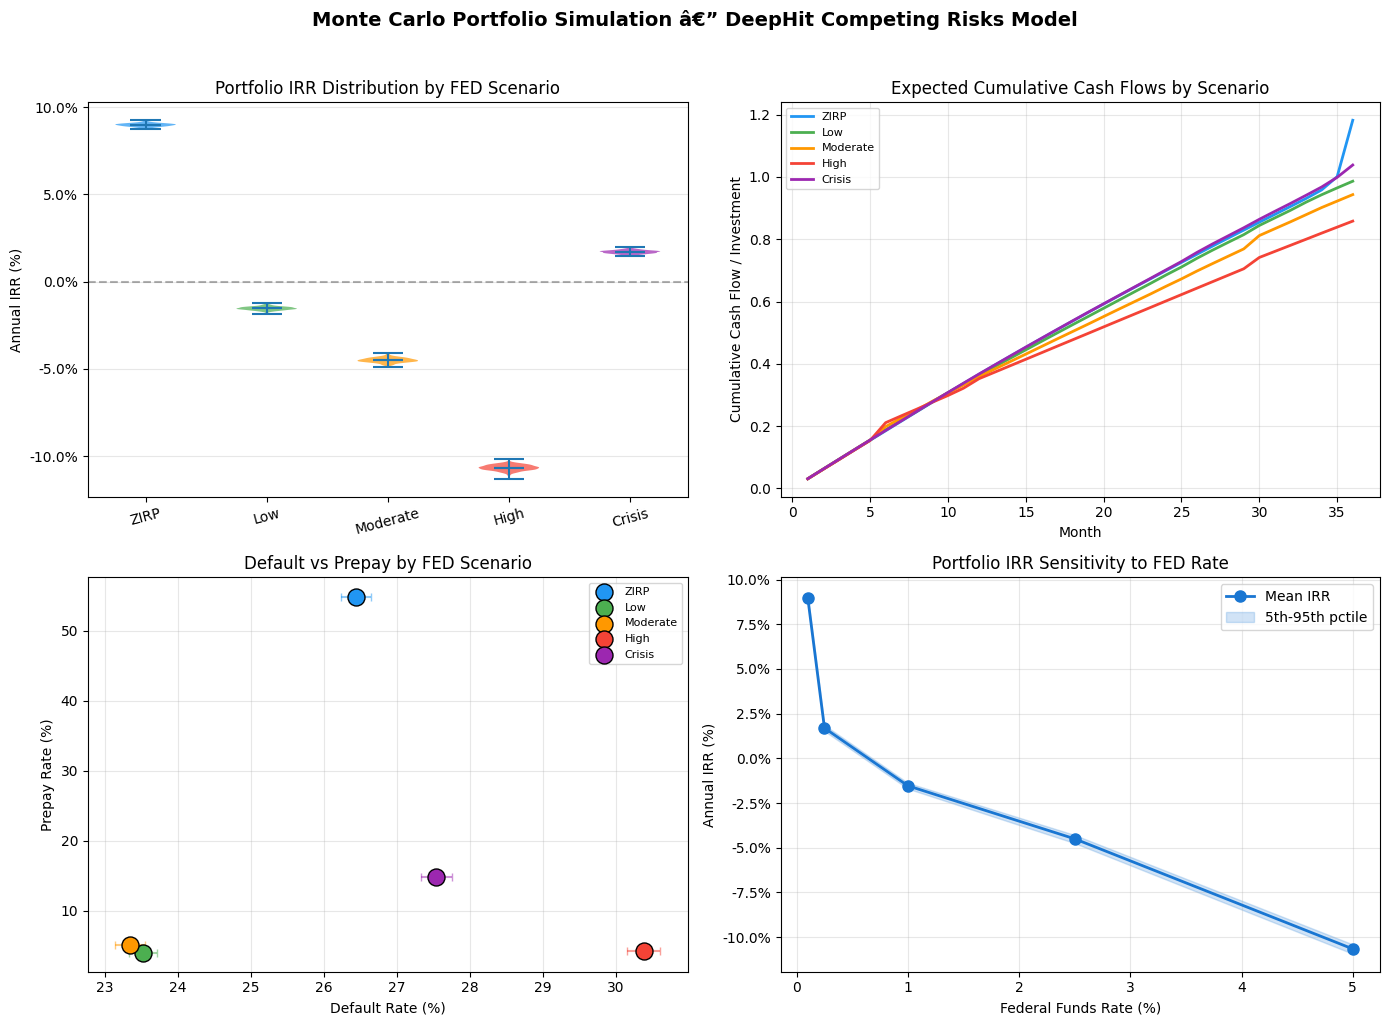


MONTE CARLO SIMULATION SUMMARY
Portfolio: 43,446 loans | $479,970,092 invested
Simulations: 500 per scenario | Recovery rate: 10%
Model chain: FED â†’ Model 2 (T-bill) â†’ Model 1 (APR) â†’ Model 3 (DeepHit CIF) â†’ Cash Flows
------------------------------------------------------------------------------------------
Scenario               Mean IRR    IRR Std   5th %ile  95th %ile    VaR(5%)
------------------------------------------------------------------------------------------
ZIRP (0.1%)              8.98%     0.09%     8.82%     9.13%     8.82%
Low (1.0%)              -1.54%     0.10%    -1.70%    -1.38%    -1.70%
Moderate (2.5%)         -4.50%     0.14%    -4.75%    -4.29%    -4.75%
High (5.0%)            -10.67%     0.16%   -10.94%   -10.41%   -10.94%
Crisis (0.25%)           1.70%     0.10%     1.53%     1.86%     1.53%


In [9]:
# ===== 7. VISUALIZATION =====
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
scenario_names = list(scenarios.keys())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

# --- Plot 1: IRR distribution (violin plot) ---
ax = axes[0, 0]
irr_data = [mc_results[name]['irrs'] * 100 for name in scenario_names]
parts = ax.violinplot(irr_data, positions=range(len(scenario_names)), showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(scenario_names)))
ax.set_xticklabels([s.split('(')[0].strip() for s in scenario_names], rotation=15)
ax.set_ylabel('Annual IRR (%)')
ax.set_title('Portfolio IRR Distribution by FED Scenario')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: Expected cumulative cash flows ---
ax = axes[0, 1]
months = np.arange(1, 37)
for i, name in enumerate(scenario_names):
    cf = results[name]['monthly_cf']
    cumcf = np.cumsum(cf) / results[name]['total_invested']
    ax.plot(months, cumcf, label=name.split('(')[0].strip(), color=colors[i], linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Cash Flow / Investment')
ax.set_title('Expected Cumulative Cash Flows by Scenario')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 3: Default rate vs Prepay rate ---
ax = axes[1, 0]
for i, name in enumerate(scenario_names):
    dr = mc_results[name]['default_rates']
    pr = mc_results[name]['prepay_rates']
    ax.scatter(dr.mean() * 100, pr.mean() * 100, s=150, c=colors[i], 
               label=name.split('(')[0].strip(), zorder=5, edgecolors='black')
    # Error bars (1 std)
    ax.errorbar(dr.mean() * 100, pr.mean() * 100,
                xerr=dr.std() * 100, yerr=pr.std() * 100,
                c=colors[i], alpha=0.5, capsize=3)
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Prepay Rate (%)')
ax.set_title('Default vs Prepay by FED Scenario')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Plot 4: Sensitivity curve â€” IRR vs FED rate ---
ax = axes[1, 1]
fed_rates = [scenarios[name] for name in scenario_names]
mean_irrs = [np.nanmean(mc_results[name]['irrs']) * 100 for name in scenario_names]
irr_5th = [np.nanpercentile(mc_results[name]['irrs'], 5) * 100 for name in scenario_names]
irr_95th = [np.nanpercentile(mc_results[name]['irrs'], 95) * 100 for name in scenario_names]

# Sort by FED rate for clean line
sort_idx = np.argsort(fed_rates)
fed_sorted = [fed_rates[i] for i in sort_idx]
irr_sorted = [mean_irrs[i] for i in sort_idx]
irr5_sorted = [irr_5th[i] for i in sort_idx]
irr95_sorted = [irr_95th[i] for i in sort_idx]

ax.plot(fed_sorted, irr_sorted, 'o-', color='#1976D2', linewidth=2, markersize=8, label='Mean IRR')
ax.fill_between(fed_sorted, irr5_sorted, irr95_sorted, alpha=0.2, color='#1976D2', label='5th-95th pctile')
ax.set_xlabel('Federal Funds Rate (%)')
ax.set_ylabel('Annual IRR (%)')
ax.set_title('Portfolio IRR Sensitivity to FED Rate')
ax.legend()
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

plt.suptitle('Monte Carlo Portfolio Simulation â€” DeepHit Competing Risks Model', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Print final summary ---
print('\n' + '=' * 90)
print('MONTE CARLO SIMULATION SUMMARY')
print('=' * 90)
print(f'Portfolio: {len(portfolio):,} loans | ${results[scenario_names[0]]["total_invested"]:,.0f} invested')
print(f'Simulations: {K} per scenario | Recovery rate: {RECOVERY_RATE:.0%}')
print(f'Model chain: FED â†’ Model 2 (T-bill) â†’ Model 1 (APR) â†’ Model 3 (DeepHit CIF) â†’ Cash Flows')
print('-' * 90)
print(f'{"Scenario":<20} {"Mean IRR":>10} {"IRR Std":>10} {"5th %ile":>10} {"95th %ile":>10} {"VaR(5%)":>10}')
print('-' * 90)
for name in scenario_names:
    irrs = mc_results[name]['irrs']
    var5 = np.nanpercentile(irrs, 5)  # Value at Risk (5th percentile)
    print(f'{name:<20} {np.nanmean(irrs):>9.2%} {np.nanstd(irrs):>9.2%} '
          f'{var5:>9.2%} {np.nanpercentile(irrs, 95):>9.2%} {var5:>9.2%}')
print('=' * 90)